# Do open-neighbourhood concepts spread? Fresh-cohort test (demo)

This notebook demos the experiment **"Do open-neighbourhood concepts spread? Fresh-cohort test"**. It is a single-unseal check of the RQ1 openness claim (from EXP8) on a new cohort of OpenAlex legacy concepts with 2015-2017 onsets.

**The question.** A concept's *early ego-network* is the network of concepts it co-occurs with in its first years. Is a concept with a more **open** early ego-network (new edges, many communities, high participation, novel residual links, low density, low edge persistence) later used across **more disciplines**? Breadth is measured by `O2r_m50`, the rarefied number of venue fields at m = 50 papers, 6-8 years after onset. The test controls for the B5 baseline (volume, growth, off-home share, entropy, reach) and further covariates.

**OPEN** is the mean of six signed, z-scored ego-network components. Its clip/centre/scale constants were **frozen** on the 12,499 EXP5 concepts before the unseal. It is built from ALL papers or HOME-field papers only.

**What the original `method.py` is.** It is an *orchestrator*: it runs about 25 pipeline scripts in order. These cover OpenAlex snapshot passes, the LLM precision gate, LLM concept typing, ego-network construction, the sealed outcome unseal, audits and figures. That full pipeline needs a 100+ GB OpenAlex snapshot and paid LLM calls, so it cannot run in Colab.

**What this demo runs.** It does two things:
1. It shows the original orchestrator (`method.py`) verbatim, run with `--list` so it only prints the step order.
2. It runs the artifact's **independent re-derivation of the headline numbers** (`rederive.py`) nearly verbatim on a 100-concept subset of the cohort (`mini_demo_data.json`). This script uses only the raw per-concept tables and the frozen constants. It:
   - rebuilds OPEN_home / OPEN_all from the six raw components;
   - computes the partial Spearman of OPEN with `O2r_m50` at ladder rung R2, with a bootstrap CI;
   - runs a shuffled-outcome placebo and a random-OPEN placebo;
   - compares prediction quality of the frozen B5 model with the frozen B5 + OPEN_home model.

Full-cohort result (n = 573): OPEN_home partial Spearman is **+0.091 [+0.013, +0.171]** at R2. The verdict is CONFIRMED but marginal, and there is no practical prediction gain (B5 Spearman 0.768 vs 0.770). With only 100 concepts, the demo estimates are much noisier.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used here are pre-installed on Colab -- install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'pyarrow==18.1.0')

## Imports
The first block is the original import block of `method.py` (the orchestrator). The second is the original import block of `rederive.py` (the analysis this demo runs). `matplotlib` is added for the final visualization.

In [2]:
# --- method.py (orchestrator) imports, as in the original ---
from __future__ import annotations

import argparse
import subprocess
import sys
from pathlib import Path

# --- rederive.py imports, as in the original ---
import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# --- added for the notebook's visualization ---
import matplotlib.pyplot as plt

## Data loading
`mini_demo_data.json` holds 100 cohort concepts, sampled proportionally across analysis group × onset year. All of them have OPEN_home, OPEN_all, the outcome and the frozen predictions. It also holds the **frozen OPEN constants** (`open_constants`, from `results/frozen_spec.json`) and the full-cohort `rederive.json` result for comparison. The file is loaded from GitHub, with a local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-4/experiment-10/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["n_examples"], "concepts;", data["description"][:200], "...")

100 concepts; 100 concepts from the fresh 2015-2017 OpenAlex onset cohort (stratified by analysis group x onset year, restricted to concepts with OPEN_home, OPEN_all, the O2r_m50 outcome and frozen predictions). Ea ...


## Config
The tunable parameters of the re-derivation. In the original script they are hard-coded as `range(400)` bootstrap draws, `range(200)` within-group permutations and the complete cohort. On 100 concepts the original values run in seconds, so the demo uses them unchanged.

In [5]:
N_EXAMPLES = 100   # concepts used from mini_demo_data.json (max 100; the original used the full cohort, n = 573 / 630)
N_BOOT = 400       # bootstrap draws for the psp CI (original: 400)
N_PERM = 200       # within-group shuffled-outcome placebo draws (original: 200)

## 1. The original orchestrator (`method.py`)
This is `method.py` verbatim. `STEPS` lists every pipeline stage in execution order:
- `s0`: pre-registration hash seal
- `s1`: candidate cohort
- `passC`: OpenAlex snapshot pass
- `s3`: coverage audit
- `s4`: LLM precision gate
- `s7`: ego networks for the EXP5 and cohort frames
- `s6`: covariates
- `s5`: LLM concept typing and its gate
- `s8`: selection on EXP5
- `s9`: the **single unseal** of the sealed outcomes
- then the learned-model replication, audit, tests, figures/outputs, report and `rederive`

`subprocess.run` would launch each script. Those scripts need the OpenAlex snapshot, so the only change here is calling `main()` with `--list`, which prints the step order without running anything.

In [6]:
ROOT = Path.cwd()  # original: Path(__file__).resolve().parent (no __file__ in a notebook)
PY = sys.executable
STEPS = [
    ("s0", [PY, "s0_prereg.py"]),
    ("s1", [PY, "s1_candidates.py"]),
    ("passC", [PY, "passC.py", "--workers", "9"]),
    ("passC_merge", [PY, "passC.py", "--merge"]),
    ("s3", [PY, "s3_checks.py"]),
    ("s4", [PY, "s4_gate.py", "run"]),
    ("s4_retry", [PY, "s4_gate.py", "retry"]),
    ("s7_exp5", [PY, "s7_ego.py", "--frame", "exp5", "--builds", "all,home,sizematch", "--workers", "3", "--chunk", "200"]),
    ("s7_cohort", [PY, "s7_ego.py", "--frame", "cohort", "--builds", "all,home,sizematch", "--workers", "3", "--chunk", "50"]),
    ("s7_cohort_full", [PY, "s7_ego.py", "--frame", "cohort", "--builds", "full", "--workers", "5", "--chunk", "20",
                        "--tag", "_full"]),
    ("s6", [PY, "s6_covariates.py"]),
    ("s5_exp5", [PY, "s5_typing.py", "exp5"]),
    ("s5_cohort", [PY, "s5_typing.py", "cohort"]),
    ("s5_bench", [PY, "s5_typing.py", "bench"]),
    ("s5_sheet", [PY, "s5_typing.py", "sheet"]),
    ("s5_gate", [PY, "s5_typing.py", "gate"]),
    ("s5_v2", [PY, "-c", "import subprocess,sys;[subprocess.run([sys.executable,'s5_typing.py',c,'--prompt','v2'],check=True) "
                          "for c in ('exp5','cohort','bench','gate')]"]),
    ("s5_m2all", [PY, "s5_typing.py", "m2all", "--prompt", "v2"]),
    ("s8", [PY, "s8_select.py", "--nboot", "500"]),
    ("s9", [PY, "s9_unseal.py"]),
    ("learned", [PY, "-c", "import subprocess,sys;[subprocess.run([sys.executable,'s_learned.py',c],check=True) "
                           "for c in ('validate','features','score')]"]),
    ("audit", [PY, "audit.py"]),
    ("tests", [PY, "-c", "import subprocess,sys;[subprocess.run([sys.executable,t],check=True) for t in "
                         "('tests/test_output.py','tests/t_ego_flags.py','tests/t_outcomes.py','tests/test_units.py')]"]),
    ("outputs", [PY, "make_outputs.py"]),
    ("report", [PY, "make_report.py"]),
    ("rederive", [PY, "rederive.py"]),
]


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--only")
    ap.add_argument("--from", dest="start")
    ap.add_argument("--list", action="store_true")
    a = ap.parse_args()
    names = [n for n, _ in STEPS]
    if a.list:
        print("\n".join(names))
        return
    todo = STEPS
    if a.only:
        todo = [s for s in STEPS if s[0] == a.only]
    elif a.start:
        todo = STEPS[names.index(a.start):]
    for name, cmd in todo:
        print(f"== {name}: {' '.join(cmd[:4])}", flush=True)
        subprocess.run(cmd, cwd=ROOT, check=True)


# notebook: list the step order only (running the steps needs the OpenAlex snapshot + LLM access)
sys.argv = ["method.py", "--list"]
main()

s0
s1
passC
passC_merge
s3
s4
s4_retry
s7_exp5
s7_cohort
s7_cohort_full
s6
s5_exp5
s5_cohort
s5_bench
s5_sheet
s5_gate
s5_v2
s5_m2all
s8
s9
learned
audit
tests
outputs
report
rederive


## 2. Load the per-concept tables (`rederive.py` setup)
The original reads three tables and one JSON file:
- `data/features_cohort.parquet`: raw ego-network components and covariates;
- `data/outcomes_cohort.parquet`: the `O2r_m50` outcome;
- `data/cohort_predictions.parquet`: the frozen predictions;
- `results/frozen_spec.json`: the frozen constants.

Here the same frames `F`, `O`, `P` and `spec` are built from `data`. After this cell, the code is the original.

`SIGN` holds the pre-registered direction of each component. Openness means **more** new edges, communities, participation and residual novelty, and **less** ego density and edge persistence.

In [7]:
ex = pd.DataFrame(data["examples"]).iloc[:N_EXAMPLES]
spec = {"open_constants": data["open_constants"]}                      # original: results/frozen_spec.json
F = ex.drop(columns=["O2r_m50", "pred_b5", "pred_b5_open"])            # original: data/features_cohort.parquet
O = ex[["ci", "O2r_m50"]]                                               # original: data/outcomes_cohort.parquet
D = F.merge(O, on="ci")
SIGN = {"new_edge_rate": 1, "n_comm_W3": 1, "participation": 1, "NOV_res": 1, "ego_density_W3": -1,
        "edge_persistence": -1}
print(D.shape)
D[["name", "t0", "agroup", "type", "OPEN_home", "OPEN_all", "O2r_m50"]].head()

(100, 30)


,name,t0,agroup,type,OPEN_home,OPEN_all,O2r_m50
0,Potassium-ion battery,2017,CS+Eng,object,0.467465,0.237999,4.550383
1,Succinylation,2015,BGM+Med,method,0.009994,0.948703,7.535694
2,Viral shedding,2016,BGM+Med,property,0.268592,-0.238498,4.557085
3,Human–wildlife conflict,2015,LIFEENV,topic,-0.283646,-0.635741,4.481414
4,Multi-task learning,2016,CS+Eng,method,0.294485,0.299857,7.856290


## 3. OPEN score, ladder design matrix and partial Spearman
- **`open_score(build)`** does four things for each of the six components. It clips the component to the frozen `[lo, hi]` range, centres and scales it with the frozen EXP5 `mu` / `sd`, and applies the sign. It then takes the mean over components. A score is kept only if at least 4 components exist. For the HOME build it also needs at least 10 home-field early papers.
- **`design(d)`** builds rung **R2** of the covariate ladder:
  - the intercept;
  - the ranks of the B5 covariates (`logvol`, `growth_c`, `offhome_share`, `entropy`, `reach`) plus `CONTACT_REACH`;
  - onset-year dummies;
  - LLM concept-type dummies, the `generic` flag and level dummies.
- **`psp(x, y, X)`** is the partial Spearman correlation. It ranks x and y, residualises both on X with a QR projection, and correlates the residuals. Collinear or empty dummy columns are dropped first, which matters on a 100-concept subset where some dummy levels are empty.

In [8]:
def open_score(build):
    c = spec["open_constants"][build]
    zs = []
    for k, s in SIGN.items():
        v = D[f"{k}__{build}"].clip(c[k]["lo"], c[k]["hi"])
        zs.append(s * (v - c[k]["mu"]) / c[k]["sd"])
    Z = pd.concat(zs, axis=1)
    o = Z.mean(axis=1, skipna=True).where(Z.notna().sum(axis=1) >= 4)
    if build != "all":
        o = o.where(D.n_home_early >= 10)
    return o


def design(d):
    cont = ["logvol", "growth_c", "offhome_share", "entropy", "reach", "CONTACT_REACH"]
    X = [np.ones(len(d))] + [d[c].rank().to_numpy() for c in cont]
    for y in (2016, 2017):
        X.append((d.t0 == y).to_numpy(float))
    for t in ("method", "object", "property"):
        X.append((d["type"] == t).to_numpy(float))
    X.append(d["generic"].to_numpy(float))
    for lv in (3, 4, 5):
        X.append((d.level == lv).to_numpy(float))
    return np.column_stack(X)


def psp(x, y, X):
    keep = np.abs(np.linalg.qr(X)[1].diagonal()) > 1e-9      # drop collinear / empty dummy columns
    Q, _ = np.linalg.qr(X[:, keep])
    rx = pd.Series(x).rank().to_numpy(); ry = pd.Series(y).rank().to_numpy()
    rx = rx - Q @ (Q.T @ rx); ry = ry - Q @ (Q.T @ ry)
    return float(np.corrcoef(rx, ry)[0, 1])

## 4. Re-derive OPEN, the R2 partial Spearman and its CI, plus the placebos
For each build (HOME, ALL) the loop does three things:
1. It checks that the rebuilt OPEN matches the frozen table (`max_abs_diff` should be 0).
2. It estimates the R2 partial Spearman of OPEN with `O2r_m50`, with an `N_BOOT`-draw percentile bootstrap CI.
3. For HOME only, it runs two placebos. The first shuffles the outcome **within analysis group** `N_PERM` times; the observed |psp| should sit in the tail of that null. The second computes the psp for a pure-noise OPEN, which should be about 0.

The only change from the original is that `range(400)` / `range(200)` became `range(N_BOOT)` / `range(N_PERM)`.

In [9]:
out = {}
for b in ("home", "all"):
    o = open_score(b)
    out[f"OPEN_{b}_max_abs_diff_vs_frozen_table"] = float(np.nanmax(np.abs(o - F[f"OPEN_{b}"])))
    d = D.assign(o=o).dropna(subset=["o", "O2r_m50", "logvol", "growth_c", "offhome_share", "entropy", "reach"])
    d = d.reset_index(drop=True)
    est = psp(d.o.to_numpy(), d.O2r_m50.to_numpy(), design(d))
    rng = np.random.default_rng(1)
    bs = []
    for _ in range(N_BOOT):
        i = rng.integers(0, len(d), len(d))
        di = d.iloc[i].reset_index(drop=True)
        bs.append(psp(di.o.to_numpy(), di.O2r_m50.to_numpy(), design(di)))
    out[f"OPEN_{b}_psp_R2"] = {"n": len(d), "est": est, "ci95_400boot": [float(np.percentile(bs, 2.5)),
                                                                          float(np.percentile(bs, 97.5))]}
    out[f"_boot_{b}"] = bs  # notebook addition: keep the bootstrap draws for the plot below
    if b == "home":
        # placebo 1: within-group shuffled outcome; placebo 2: random OPEN
        perm = []
        for _ in range(N_PERM):
            y = d.O2r_m50.to_numpy().copy()
            for g in d.agroup.unique():
                m = (d.agroup == g).to_numpy()
                y[m] = rng.permutation(y[m])
            perm.append(psp(d.o.to_numpy(), y, design(d)))
        perm = np.abs(perm)
        out["placebo_shuffled_outcome"] = {"q95_abs": float(np.percentile(perm, 95)),
                                           "share_ge_observed": float((perm >= abs(est)).mean())}
        out["_perm_abs"] = perm  # notebook addition: keep the placebo null for the plot below
        rnd = psp(rng.normal(size=len(d)), d.O2r_m50.to_numpy(), design(d))
        out["placebo_random_open_psp"] = rnd

## 5. Prediction check: frozen B5 vs frozen B5 + OPEN_home
Both OLS models were fitted on the EXP5 frame and frozen before the unseal. This cell compares the Spearman correlation of each model's predictions with the realised `O2r_m50`. On the full cohort the gain is only +0.002, meaning OPEN adds no practical prediction.

In [10]:
P = ex[["ci", "pred_b5", "pred_b5_open"]].merge(O, on="ci").dropna()   # original: data/cohort_predictions.parquet
s0, s1 = spearmanr(P.pred_b5, P.O2r_m50)[0], spearmanr(P.pred_b5_open, P.O2r_m50)[0]
out["prediction_spearman"] = {"n": len(P), "B5": float(s0), "B5_plus_OPEN_home": float(s1), "diff": float(s1 - s0)}
print(json.dumps({k: v for k, v in out.items() if not k.startswith("_")}, indent=1))

{
 "OPEN_home_max_abs_diff_vs_frozen_table": 0.0,
 "OPEN_home_psp_R2": {
  "n": 100,
  "est": 0.1053259175844299,
  "ci95_400boot": [
   -0.13246781718093978,
   0.3340983296624912
  ]
 },
 "placebo_shuffled_outcome": {
  "q95_abs": 0.193062073472901,
  "share_ge_observed": 0.375
 },
 "placebo_random_open_psp": -0.08769447149512687,
 "OPEN_all_max_abs_diff_vs_frozen_table": 0.0,
 "OPEN_all_psp_R2": {
  "n": 100,
  "est": 0.12316177235847509,
  "ci95_400boot": [
   -0.12727413815702454,
   0.3261704005131703
  ]
 },
 "prediction_spearman": {
  "n": 100,
  "B5": 0.7932997098736871,
  "B5_plus_OPEN_home": 0.799216319284483,
  "diff": 0.005916609410795859
 }
}


## 6. Results: demo subset vs full cohort
The table below puts the demo numbers (100 concepts) next to the artifact's full-cohort `rederive.json`. The figure has three panels:
- **(a)** the R2 partial Spearman of OPEN_home and OPEN_all with 95% bootstrap CIs, demo vs full cohort;
- **(b)** the bootstrap distributions against the shuffled-outcome placebo null;
- **(c)** predicted vs realised breadth for the frozen B5 and B5 + OPEN_home models.

With n ≈ 100 the CIs are about 2.4× wider than on the full cohort (n = 573), so the demo estimate can land on either side of 0. The full-cohort numbers are the reference.

                                                                         demo                      full cohort
quantity                                                                                                      
psp(OPEN_home, O2r_m50 | R2)                  +0.105 [-0.132, +0.334] (n=100)  +0.091 [+0.011, +0.165] (n=573)
OPEN_home rebuild max |diff| vs frozen table                         0.00e+00                         0.00e+00
psp(OPEN_all, O2r_m50 | R2)                   +0.123 [-0.127, +0.326] (n=100)  +0.174 [+0.096, +0.259] (n=630)
OPEN_all rebuild max |diff| vs frozen table                          0.00e+00                         0.00e+00
shuffled placebo: q95 |psp|                                             0.193                            0.072
shuffled placebo: share |psp| >= observed                               0.375                            0.015
random-OPEN placebo psp                                                -0.088                           -0.027
p

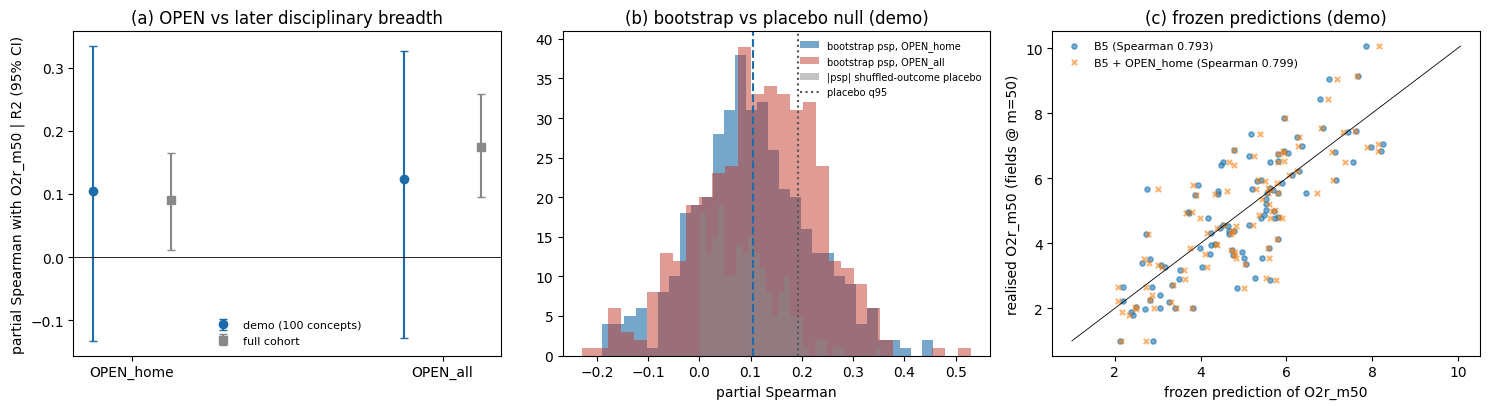

In [11]:
full = data["full_cohort_rederive_result"]
rows = []
for b in ("home", "all"):
    k = f"OPEN_{b}_psp_R2"
    rows.append({"quantity": f"psp(OPEN_{b}, O2r_m50 | R2)",
                 "demo": f"{out[k]['est']:+.3f} [{out[k]['ci95_400boot'][0]:+.3f}, {out[k]['ci95_400boot'][1]:+.3f}] (n={out[k]['n']})",
                 "full cohort": f"{full[k]['est']:+.3f} [{full[k]['ci95_400boot'][0]:+.3f}, {full[k]['ci95_400boot'][1]:+.3f}] (n={full[k]['n']})"})
    rows.append({"quantity": f"OPEN_{b} rebuild max |diff| vs frozen table",
                 "demo": f"{out[f'OPEN_{b}_max_abs_diff_vs_frozen_table']:.2e}",
                 "full cohort": f"{full[f'OPEN_{b}_max_abs_diff_vs_frozen_table']:.2e}"})
rows.append({"quantity": "shuffled placebo: q95 |psp|", "demo": f"{out['placebo_shuffled_outcome']['q95_abs']:.3f}",
             "full cohort": f"{full['placebo_shuffled_outcome']['q95_abs']:.3f}"})
rows.append({"quantity": "shuffled placebo: share |psp| >= observed", "demo": f"{out['placebo_shuffled_outcome']['share_ge_observed']:.3f}",
             "full cohort": f"{full['placebo_shuffled_outcome']['share_ge_observed']:.3f}"})
rows.append({"quantity": "random-OPEN placebo psp", "demo": f"{out['placebo_random_open_psp']:+.3f}",
             "full cohort": f"{full['placebo_random_open_psp']:+.3f}"})
for k in ("B5", "B5_plus_OPEN_home", "diff"):
    rows.append({"quantity": f"prediction Spearman: {k}", "demo": f"{out['prediction_spearman'][k]:+.3f}",
                 "full cohort": f"{full['prediction_spearman'][k]:+.3f}"})
summary = pd.DataFrame(rows).set_index("quantity")
print(summary.to_string())

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
# (a) psp with CI: demo vs full
ax = axs[0]
for j, (lab, src) in enumerate((("demo (100 concepts)", out), ("full cohort", full))):
    for i, b in enumerate(("home", "all")):
        r = src[f"OPEN_{b}_psp_R2"]
        ax.errorbar(i + (j - 0.5) * 0.25, r["est"], yerr=[[r["est"] - r["ci95_400boot"][0]], [r["ci95_400boot"][1] - r["est"]]],
                    fmt="o" if j == 0 else "s", color=["#1b6ca8", "#888888"][j], capsize=3, label=lab if i == 0 else None)
ax.axhline(0, color="k", lw=0.6)
ax.set_xticks([0, 1], ["OPEN_home", "OPEN_all"])
ax.set_ylabel("partial Spearman with O2r_m50 | R2 (95% CI)")
ax.set_title("(a) OPEN vs later disciplinary breadth")
ax.legend(frameon=False, fontsize=8)
# (b) bootstrap vs placebo null
ax = axs[1]
ax.hist(out["_boot_home"], bins=30, alpha=0.6, color="#1b6ca8", label="bootstrap psp, OPEN_home")
ax.hist(out["_boot_all"], bins=30, alpha=0.5, color="#c0392b", label="bootstrap psp, OPEN_all")
ax.hist(out["_perm_abs"], bins=30, alpha=0.5, color="#888888", label="|psp| shuffled-outcome placebo")
ax.axvline(out["OPEN_home_psp_R2"]["est"], color="#1b6ca8", ls="--")
ax.axvline(out["placebo_shuffled_outcome"]["q95_abs"], color="#555555", ls=":", label="placebo q95")
ax.set_xlabel("partial Spearman")
ax.set_title("(b) bootstrap vs placebo null (demo)")
ax.legend(frameon=False, fontsize=7)
# (c) predictions vs outcome
ax = axs[2]
ax.scatter(P.pred_b5, P.O2r_m50, s=14, alpha=0.6, label=f"B5 (Spearman {s0:.3f})")
ax.scatter(P.pred_b5_open, P.O2r_m50, s=14, alpha=0.6, marker="x", label=f"B5 + OPEN_home (Spearman {s1:.3f})")
lim = [min(P.pred_b5.min(), P.O2r_m50.min()), max(P.pred_b5.max(), P.O2r_m50.max())]
ax.plot(lim, lim, color="k", lw=0.6)
ax.set_xlabel("frozen prediction of O2r_m50")
ax.set_ylabel("realised O2r_m50 (fields @ m=50)")
ax.set_title("(c) frozen predictions (demo)")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()